# Setup

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [3]:
import os
import json
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import hausdorff_distance

from data_handlers.data_loading.dataset_registry import build_dataset, get_dataset_config_path
from utils.file_management import serialize_config, get_version_folder
from utils.plots import show_images
from utils.augmentation import GeometricAug, NoiseAug
from model import EncoderDecoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


# Generic Config
Same keys for every dataset — these are experiment choices, not dataset properties.
`dataset_config['num_classes']` gets filled in below, by whichever dataset is selected.

In [4]:
dataset_config = {
    'batch_size': 32,
    'dataset_seed': 1,
    'labeled_fraction': 0.00,
    'input_size': (256, 256),
}
# 'num_classes' and 'in_channels' are NOT set here — they're dataset properties, not
# experiment choices, so build_dataset() returns them and they get filled in below
# (see the "Generic data loaders" cell). in_channels is 1 for the grayscale
# ultrasound datasets and 3 for RGB CelebAMask-HQ.

# ============================================================
# DATASET SELECTION
 All dataset-specific values (paths, channels, sites, ...) live in that
 dataset's own JSON config under data_loading/<Dataset>/dataset_config.json
 — see dataset_registry.py. Switching datasets is just changing the name
 below (once the target dataset has a build_dataset() registered).
# ============================================================

In [5]:
DATASET_NAME = 'celebamaskhq'

## Run selection
Resolved *before* the loaders are built (not in "Training Run Config" below), because
building the loaders needs to already know whether this is a fresh run or a resume —
see the dataset-config snapshot note below.

In [6]:
# Set to a run number (e.g. 37) to resume that run, or None to start fresh
LOAD_RUN = None

# Separate run root per dataset, so runs from different datasets never collide or
# share a version counter (get_version_folder's index.txt is per-root).
root = os.path.join('cache/model_weights/semisup', DATASET_NAME)

if LOAD_RUN is not None:
    index_folder = os.path.join(root, str(LOAD_RUN))
    print(f'Resuming run {LOAD_RUN} at {index_folder}')
else:
    index_folder = get_version_folder(root)
    print(f'Starting a new run at {index_folder}')

# Dataset-config snapshot: a fresh run copies the CURRENT
# data_handlers/data_loading/<Dataset>/dataset_config.json into this run's folder, so
# later edits to that file (train_channels, sites, max_unlabeled_samples,
# same_site_test, ...) never retroactively change what an already-started run means.
# Resuming loads that saved snapshot back instead of the live file — via
# build_dataset()'s dataset_config_path kwarg, below — so LOAD_RUN reproduces the
# exact same dataset scenario the run originally started with.
run_dataset_config_path = os.path.join(index_folder, 'dataset_config.json')
if LOAD_RUN is not None:
    print(f'Using this run\'s saved dataset config: {run_dataset_config_path}')
else:
    shutil.copyfile(get_dataset_config_path(DATASET_NAME), run_dataset_config_path)
    print(f'Snapshotted the live dataset config to {run_dataset_config_path}')

Starting a new run at cache/model_weights/semisup/celebamaskhq/7
Snapshotted the live dataset config to cache/model_weights/semisup/celebamaskhq/7/dataset_config.json


## Generic data loaders
Every dataset-specific concern — paths, whether/how it does a semi-supervised split,
where val comes from, DataLoader construction — lives entirely inside that dataset's
own `build_dataset()` (see `dataset_registry.py`). This notebook just asks for the
four loaders + num_classes and never special-cases any dataset by name.

In [7]:
labeled_loader, unlabeled_loader, val_loader, test_loader, num_classes, in_channels = build_dataset(
    DATASET_NAME,
    batch_size=dataset_config['batch_size'],
    labeled_fraction=dataset_config['labeled_fraction'],
    seed=dataset_config['dataset_seed'],
    dataset_config_path=run_dataset_config_path,
)
# Dataset-derived, filled in per-dataset exactly like num_classes — the notebook
# never hardcodes or special-cases either. in_channels feeds EncoderDecoder below.
dataset_config['num_classes'] = num_classes
dataset_config['in_channels'] = in_channels

val_batches = len(val_loader) if val_loader is not None else 0
print(f'num_classes: {num_classes} | in_channels: {in_channels}')
print(f'Labeled batches: {len(labeled_loader)} | Unlabeled batches: {len(unlabeled_loader)} | '
      f'Val batches: {val_batches} | Test batches: {len(test_loader)}')

SemiSupervisedDatasetWrapper: 24183 total samples (1 labeled, 24182 unlabeled)
num_classes: 8 | in_channels: 3
Labeled batches: 1 | Unlabeled batches: 756 | Val batches: 188 | Test batches: 177


## Training Run Config (generic)

In [8]:
# LOAD_RUN / root / index_folder are already resolved in the "Run selection" cell
# above (before the loaders, since building them needs to know that too) — reused
# here, not recomputed, so get_version_folder's mkdir+counter-increment only ever
# happens once per fresh run.
if LOAD_RUN is not None:
    with open(os.path.join(index_folder, 'config.json')) as f:
        train_config = json.load(f)
    print(f'Loaded config from run {LOAD_RUN}:')
else:
    train_config = {
        'lr': 1e-4,
        'epochs': 100,
        'bottleneck_dim': 1024,
        'number_of_vectors': 1024,
        # single flag applied to ALL vectorizers (one vectorizer per class)
        'vectorizers_mat_mul': True,
        # augmentations (GeometricAug + NoiseAug)
        'geo_aug_degrees': 10,
        'geo_aug_translate': (0.1, 0.1),
        'geo_aug_scale': (0.9, 1.1),
        'geo_aug_shear': 10,
        'noise_std': 0.05,
        'brightness': 0.2,
        'contrast': 0.2,
        # loss weights
        'reconstruction_weight': 25.0,
        'segmentation_weight': 1.0,
        # Reconstruction-loss warmup: scale the reconstruction weight from
        # reconstruction_warmup_start * reconstruction_weight (0.0 => literally 0) up
        # to the full reconstruction_weight, linearly over the first
        # reconstruction_warmup_epochs epochs, then hold flat. Applied from step 0 the
        # reconstruction term drags one vectorizer into reconstructing everything and
        # softmax(seg) collapses onto it (background stops being predicted -> Dice ~0
        # for the first few epochs). Warming it up lets the model fit per-class
        # positions from the labels first, then adapt texture. 0 epochs = off.
        # Lengthen this if the early collapse persists; see the training-loop cell.
        'reconstruction_warmup_epochs': 5,
        'reconstruction_warmup_start': 0.0,
        'eval_every_n_epochs': 1,
        # include background (channel 0) in the segmentation Dice loss, or
        # restrict Dice to foreground classes only (CE is already foreground-only)
        'dice_include_background': True,
      
        # Best-checkpoint backups — see evaluate()'s store_checkpoints flag. Separate
        # from model_path, which is just "whatever the latest epoch saved".
        'best_dice_model_path': os.path.join(index_folder, 'best_dice_model.pt'),
        'best_hd_model_path': os.path.join(index_folder, 'best_hd_model.pt'),
        'best_scores_path': os.path.join(index_folder, 'best_scores.json'),
        'config_path': os.path.join(index_folder, 'config.json'),
    }
    
    with open(train_config['config_path'], 'w') as f:
        json.dump(serialize_config(train_config), f, indent=2)
    print('Starting fresh run:')



train_config['model_path'] = os.path.join(index_folder, 'model.pt')
train_config['config_path'] = os.path.join(index_folder, 'config.json')
# Normalize the vectorizer flag (tolerate old list-form configs).
flag = train_config['vectorizers_mat_mul']
if isinstance(flag, (list, tuple)):
    flag = flag[0]
train_config['vectorizers_mat_mul'] = bool(flag)

# Backward compatibility: configs saved before these keys existed.
train_config.setdefault('dice_include_background', True)
train_config.setdefault('eval_every_n_epochs', 1)
# Warmup defaults OFF for configs saved before it existed, so resuming an older run
# reproduces its original (un-warmed) loss schedule exactly.
train_config.setdefault('reconstruction_warmup_epochs', 0)
train_config.setdefault('reconstruction_warmup_start', 0.0)
train_config.setdefault('best_dice_model_path', os.path.join(index_folder, 'best_dice_model.pt'))
train_config.setdefault('best_hd_model_path', os.path.join(index_folder, 'best_hd_model.pt'))
train_config.setdefault('best_scores_path', os.path.join(index_folder, 'best_scores.json'))

# Best-score tracking state, used by evaluate()'s store_checkpoints flag — reloaded
# from best_scores.json if this run already has one (e.g. resuming via LOAD_RUN), so
# resuming doesn't reset what counts as "best" back to nothing.
if os.path.exists(train_config['best_scores_path']):
    with open(train_config['best_scores_path']) as f:
        best_scores = json.load(f)
    print(f"Loaded existing best scores from {train_config['best_scores_path']}")
else:
    best_scores = {}
best_dice_so_far = best_scores.get('best_dice', {}).get('dice', float('-inf'))
best_hd_so_far   = best_scores.get('best_hd',   {}).get('hd',   float('inf'))

print(json.dumps(serialize_config(train_config), indent=2))

Starting fresh run:
{
  "lr": 0.0001,
  "epochs": 100,
  "bottleneck_dim": 1024,
  "number_of_vectors": 1024,
  "vectorizers_mat_mul": true,
  "geo_aug_degrees": 10,
  "geo_aug_translate": [
    0.1,
    0.1
  ],
  "geo_aug_scale": [
    0.9,
    1.1
  ],
  "geo_aug_shear": 10,
  "noise_std": 0.05,
  "brightness": 0.2,
  "contrast": 0.2,
  "reconstruction_weight": 25.0,
  "segmentation_weight": 1.0,
  "reconstruction_warmup_epochs": 5,
  "reconstruction_warmup_start": 0.0,
  "eval_every_n_epochs": 1,
  "dice_include_background": true,
  "best_dice_model_path": "cache/model_weights/semisup/celebamaskhq/7/best_dice_model.pt",
  "best_hd_model_path": "cache/model_weights/semisup/celebamaskhq/7/best_hd_model.pt",
  "best_scores_path": "cache/model_weights/semisup/celebamaskhq/7/best_scores.json",
  "config_path": "cache/model_weights/semisup/celebamaskhq/7/config.json",
  "model_path": "cache/model_weights/semisup/celebamaskhq/7/model.pt"
}


## Model (generic)

In [9]:
model = EncoderDecoder(
    bottleneck_dim=train_config['bottleneck_dim'],
    number_of_vectors=train_config['number_of_vectors'],
    vectorizers_mat_mul=[train_config['vectorizers_mat_mul']] * dataset_config['num_classes'],
    in_channels=dataset_config['in_channels'],
    input_size=dataset_config['input_size'],
    save_path=train_config['model_path'],
).to(device)

if LOAD_RUN is not None:
    model.load_state_dict(torch.load(train_config['model_path'], map_location=device))
    print(f'Loaded state dict from {train_config["model_path"]}')

optimizer = torch.optim.Adam(model.parameters(), lr=train_config['lr'])

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Trainable parameters: 227,214,948


## Augmentations (generic)

In [10]:
temp_path =train_config['model_path']
temp_path

'cache/model_weights/semisup/celebamaskhq/7/model.pt'

In [11]:
# GeometricAug: same random transform applied to image AND label/reconstruction target
# NoiseAug:     corrupts the model input only — target stays clean
geo_aug   = GeometricAug(degrees=train_config['geo_aug_degrees'],
                         translate=train_config['geo_aug_translate'],
                         scale=train_config['geo_aug_scale'],
                         shear=train_config['geo_aug_shear'])
noise_aug = NoiseAug(noise_std=train_config['noise_std'],
                     brightness=train_config['brightness'],
                     contrast=train_config['contrast'])


def augment_samples(u_image, l_image, l_label):
    """Shared geo+noise pipeline for one (unlabeled, labeled) pair of batches.

    geo_aug runs first, with the SAME sampled transform shared between an
    image and its label. noise_aug then corrupts the model input only —
    reconstruction/segmentation targets stay clean.

    Returns: u_image_geo, u_input, l_image_geo, l_label_geo, l_input
    """
    u_image_geo              = geo_aug(u_image)
    l_image_geo, l_label_geo = geo_aug(l_image, l_label)

    u_input = noise_aug(u_image_geo)
    l_input = noise_aug(l_image_geo)

    return u_image_geo, u_input, l_image_geo, l_label_geo, l_input

## Loss Functions (generic)

In [12]:
def reconstruction_loss(rec, image, seg_logits):
    """Combine per-vectorizer reconstructions into one image using the
    segmentation logits as soft masks, then compare with the original image.

    rec        : per-vectorizer reconstruction(s), already sigmoided. MaskDecoder
                 emits (B, N, H, W) for single-channel data (grayscale ultrasound)
                 or (B, N, C, H, W) for multi-channel (RGB CelebAMask-HQ) —
                 whichever matches the model's in_channels.
    seg_logits : (B, N, H, W)  per-vectorizer segmentation logits
    image      : (B, C, H, W)  original input image
    """
    seg_probs = F.softmax(seg_logits, dim=1)   # (B, N, H, W) soft masks over vectorizers
    if rec.dim() == 5:
        # Multi-channel: weight every image channel by the same per-vectorizer mask
        # (unsqueeze the channel axis so seg_probs broadcasts over C).
        combined = (seg_probs.unsqueeze(2) * rec).sum(dim=1)   # (B, C, H, W)
        return F.mse_loss(combined, image)
    combined = (seg_probs * rec).sum(dim=1)    # (B, H, W) final image
    return F.mse_loss(combined, image.squeeze(1))


def dice_loss(probs, target_onehot, eps=1e-6):
    """probs / target_onehot : (B, C, H, W)"""
    B, C = probs.shape[:2]
    p = probs.view(B, C, -1)
    t = target_onehot.view(B, C, -1)
    inter = (p * t).sum(dim=2)
    denom = p.sum(dim=2) + t.sum(dim=2)
    return (1.0 - ((2. * inter + 1e-6) / (denom + 1e-6))).mean()


def segmentation_loss(seg_logits, labels, include_background=True):
    """CE (foreground only) + Dice.

    Labels are expected to be pre-remapped to the model's class space by the
    dataset layer: channel 0 = background, channels 1+ = foreground classes.

    include_background : if True, Dice is averaged over all channels
                          (background included). If False, Dice is restricted
                          to foreground channels only — matching the CE term,
                          which is always foreground-only regardless of this flag.
    """
    target = labels.argmax(dim=1).long()                               # (B, H, W)
    target_oh = F.one_hot(target, num_classes=seg_logits.shape[1])     # (B, H, W, C)
    target_oh = target_oh.permute(0, 3, 1, 2).float()                 # (B, C, H, W)

    # CE on foreground pixels only — flatten spatial dims so mask applies cleanly
    fg_mask = labels[:, 1:].sum(dim=1).bool()                         # (B, H, W)
    logits_flat = seg_logits.permute(0, 2, 3, 1).reshape(-1, seg_logits.shape[1])  # (B*H*W, C)
    target_flat = target.reshape(-1)                                   # (B*H*W,)
    fg_flat     = fg_mask.reshape(-1)                                  # (B*H*W,)
    ce = F.cross_entropy(logits_flat[fg_flat], target_flat[fg_flat])

    # Dice — all channels, or foreground only, depending on include_background
    probs = F.softmax(seg_logits, dim=1)
    if include_background:
        dl = dice_loss(probs, target_oh)
    else:
        dl = dice_loss(probs[:, 1:], target_oh[:, 1:])

    return ce + dl

## Metrics (generic)

In [13]:
def dice_score(pred, target, smooth=1e-6):
    """Per-sample, per-channel Dice score — no aggregation across batch or classes.

    pred, target : (B, C, H, W) or (H, W)
    Returns      : (B, C) Dice scores, or a scalar if inputs are (H, W).
    """
    assert pred.shape == target.shape, f"shape mismatch: {pred.shape} vs {target.shape}"
    assert pred.ndim >= 2, "expected at least (H, W) tensors"

    if pred.ndim == 2:
        pred = pred.unsqueeze(0).unsqueeze(0)
        target = target.unsqueeze(0).unsqueeze(0)

    pred = pred.reshape(*pred.shape[:-2], -1)
    target = target.reshape(*target.shape[:-2], -1)

    intersection = (pred * target).sum(-1)
    return (2 * intersection + smooth) / (pred.sum(-1) + target.sum(-1) + smooth)


def compute_class_dice(pred, target, num_classes):
    """Per-class Dice for one batch of predicted/target class-index maps.

    pred, target : (B, H, W) integer class-index tensors
    Returns      : (num_classes,) tensor — Dice per class for this batch
    """
    class_dice = torch.zeros(num_classes)
    for c in range(num_classes):
        p = (pred   == c).float().reshape(pred.shape[0],   -1)
        t = (target == c).float().reshape(target.shape[0], -1)
        inter = (p * t).sum(dim=1)
        denom = p.sum(dim=1) + t.sum(dim=1)
        class_dice[c] = ((2. * inter + 1e-6) / (denom + 1e-6)).mean().item()
    return class_dice


def compute_class_iou(pred, target, num_classes):
    """Per-class IoU (Jaccard) for one batch of predicted/target class-index maps.

    Same shape/aggregation convention as compute_class_dice (per-sample IoU, then
    mean over the batch), so the two are directly comparable. The mean over the
    foreground classes is the mIoU reported across the face-parsing / semi-supervised
    segmentation literature (SemanticGAN, DatasetGAN, HandsOff, ...).

    A class absent from both pred and target in a sample scores 1e-6/1e-6 = 1.0 —
    the same "absent from both -> perfect match" convention compute_class_dice and
    compute_class_hd already use.

    pred, target : (B, H, W) integer class-index tensors
    Returns      : (num_classes,) tensor — IoU per class for this batch
    """
    class_iou = torch.zeros(num_classes)
    for c in range(num_classes):
        p = (pred   == c).float().reshape(pred.shape[0],   -1)
        t = (target == c).float().reshape(target.shape[0], -1)
        inter = (p * t).sum(dim=1)
        union = p.sum(dim=1) + t.sum(dim=1) - inter
        class_iou[c] = ((inter + 1e-6) / (union + 1e-6)).mean().item()
    return class_iou


def compute_class_hd(pred, target, num_classes):
    """Per-class Hausdorff distance for one batch of predicted/target class-index maps.

    pred, target : (B, H, W) integer class-index tensors
    Returns      : (num_classes,) tensor — mean HD per class for this batch, in pixels.

    skimage.metrics.hausdorff_distance has no batched/vectorized form, so this loops
    per-sample, per-class — much slower than compute_class_dice; that's what evaluate()'s
    `compute_hd` flag is for.

    A class absent from both pred and target in a sample scores 0 (perfect match — same
    convention compute_class_dice's epsilon smoothing already uses for the empty/empty
    case). A class present in only one of pred/target has an infinite HD (skimage returns
    inf); rather than let that inf/NaN poison the running average, that sample is instead
    scored as the image diagonal — the largest distance actually possible in the image,
    i.e. the standard "worst case" stand-in for a complete miss.
    """
    diag = float(np.hypot(*pred.shape[-2:]))
    pred_np, target_np = pred.numpy(), target.numpy()

    class_hd = torch.zeros(num_classes)
    for c in range(num_classes):
        total = 0.0
        for b in range(pred_np.shape[0]):
            p, t = pred_np[b] == c, target_np[b] == c
            if not p.any() and not t.any():
                total += 0.0
            elif not p.any() or not t.any():
                total += diag
            else:
                total += hausdorff_distance(p, t)
        class_hd[c] = total / pred_np.shape[0]
    return class_hd


def print_dice_report(class_dice, num_classes):
    """Pretty-print an (accumulated) per-class Dice report from compute_class_dice."""
    print('Dice per class:')
    print(f'  Class 0 (background): {class_dice[0]:.4f}')
    for i in range(1, num_classes):
        print(f'  Class {i}:                {class_dice[i]:.4f}')
    print('\nMean Dice (foreground 1-{}): {:.4f}'.format(num_classes - 1, class_dice[1:].mean()))
    print('Mean Dice (all {}):          {:.4f}'.format(num_classes, class_dice.mean()))


def print_iou_report(class_iou, num_classes):
    """Pretty-print an (accumulated) per-class IoU report from compute_class_iou.
    The 'foreground' mean is the mIoU that lines up with the segmentation literature."""
    print('IoU per class:')
    print(f'  Class 0 (background): {class_iou[0]:.4f}')
    for i in range(1, num_classes):
        print(f'  Class {i}:                {class_iou[i]:.4f}')
    print('\nMean IoU (foreground 1-{}): {:.4f}'.format(num_classes - 1, class_iou[1:].mean()))
    print('Mean IoU (all {}):          {:.4f}'.format(num_classes, class_iou.mean()))


def print_hd_report(class_hd, num_classes):
    """Pretty-print an (accumulated) per-class Hausdorff-distance report from compute_class_hd."""
    print('Hausdorff distance per class (pixels):')
    print(f'  Class 0 (background): {class_hd[0]:.2f}')
    for i in range(1, num_classes):
        print(f'  Class {i}:                {class_hd[i]:.2f}')
    print('\nMean HD (foreground 1-{}): {:.2f}'.format(num_classes - 1, class_hd[1:].mean()))
    print('Mean HD (all {}):          {:.2f}'.format(num_classes, class_hd.mean()))

## Evaluate Function (generic)

In [14]:
def _update_best_checkpoints(class_dice, class_hd):
    """Compare this evaluation's mean Dice/HD (foreground classes only — same
    'foreground' mean print_dice_report/print_hd_report already show) against the best
    seen so far and, on a new best, save the model separately and update
    best_scores.json — using the class_dice/class_hd evaluate() already computed for
    its own report, so nothing gets evaluated twice.

    Model selection stays Dice/HD-based; mIoU is reported by evaluate() but not used
    here (foreground mean Dice and mean IoU rank models identically anyway).

    Mutates the globals best_dice_so_far / best_hd_so_far / best_scores set up in the
    "Training Run Config" cell.
    """
    global best_dice_so_far, best_hd_so_far, best_scores

    dice_score = class_dice[1:].mean().item()
    hd_score = class_hd[1:].mean().item() if class_hd is not None else None
    updated = False

    if dice_score > best_dice_so_far:
        best_dice_so_far = dice_score
        torch.save(model.state_dict(), train_config['best_dice_model_path'])
        best_scores['best_dice'] = {
            'dice': dice_score,
            'hd': hd_score,
            'dice_per_class': class_dice.tolist(),
            'hd_per_class': class_hd.tolist() if class_hd is not None else None,
        }
        print(f"New best Dice ({dice_score:.4f}) -> {train_config['best_dice_model_path']}")
        updated = True

    if hd_score is not None and hd_score < best_hd_so_far:
        best_hd_so_far = hd_score
        torch.save(model.state_dict(), train_config['best_hd_model_path'])
        best_scores['best_hd'] = {
            'dice': dice_score,
            'hd': hd_score,
            'dice_per_class': class_dice.tolist(),
            'hd_per_class': class_hd.tolist(),
        }
        print(f"New best HD ({hd_score:.2f}) -> {train_config['best_hd_model_path']}")
        updated = True

    if updated:
        with open(train_config['best_scores_path'], 'w') as f:
            json.dump(best_scores, f, indent=2)


def evaluate(loader, desc='Evaluating', compute_hd=True, store_checkpoints=False):
    """Run Dice + IoU (+ optional Hausdorff distance) over every batch in `loader`.

    loader            : any DataLoader yielding (image, label) batches — pass
                         test_loader, val_loader, or any other eval-role loader; this
                         function doesn't care which dataset it came from.
    compute_hd        : Hausdorff distance is an unbatched, per-sample/per-class
                         skimage call — much slower than the vectorized Dice/IoU. Set
                         False to skip it (e.g. for a quick per-epoch check) and get
                         only Dice + IoU back.
    store_checkpoints : if True, feed this call's own class_dice/class_hd straight
                         into _update_best_checkpoints() to maybe save a new
                         best_dice_model.pt / best_hd_model.pt — no separate
                         evaluation pass. Only pass True for a val-role call; never
                         test, which must stay untouched by any model-selection
                         decision.

    Dice and IoU (Jaccard) are two views of the same overlap; the foreground-mean IoU
    is the mIoU used across the face-parsing / semi-supervised-segmentation literature,
    so it's reported alongside Dice for direct comparison.

    Returns: (class_dice, class_iou, class_hd) — (num_classes,) tensors. class_hd is
             None if compute_hd=False.
    """
    model.eval()
    class_dice = torch.zeros(dataset_config['num_classes'])
    class_iou  = torch.zeros(dataset_config['num_classes'])
    class_hd   = torch.zeros(dataset_config['num_classes'])
    n_batches  = 0

    with torch.no_grad():
        for image, label in tqdm(loader, desc=desc):
            image = image.to(device)
            target = label.argmax(dim=1).cpu()                       # (B, H, W) class indices

            _, seg = model(image)
            pred = seg.argmax(dim=1).cpu()                           # (B, H, W)

            class_dice += compute_class_dice(pred, target, dataset_config['num_classes'])
            class_iou  += compute_class_iou(pred, target, dataset_config['num_classes'])
            if compute_hd:
                class_hd += compute_class_hd(pred, target, dataset_config['num_classes'])
            n_batches += 1

    class_dice /= n_batches
    class_iou  /= n_batches
    print_dice_report(class_dice, dataset_config['num_classes'])
    print()
    print_iou_report(class_iou, dataset_config['num_classes'])

    if compute_hd:
        class_hd /= n_batches
        print_hd_report(class_hd, dataset_config['num_classes'])
    else:
        class_hd = None

    if store_checkpoints:
        _update_best_checkpoints(class_dice, class_hd)

    return class_dice, class_iou, class_hd

## Training Loop (generic)

In [ ]:
train_losses = []
rec_losses   = []
seg_losses   = []

scaler = torch.amp.GradScaler('cuda')
torch.cuda.empty_cache()


def reconstruction_weight_for(epoch):
    """Warmed-up reconstruction weight for a given (0-indexed) epoch.

    Linear ramp: reconstruction_warmup_start * reconstruction_weight at epoch 0,
    rising to the full reconstruction_weight at epoch == reconstruction_warmup_epochs,
    flat thereafter. reconstruction_warmup_epochs == 0 disables the ramp (always full).

    NOTE: keyed off the training loop's `epoch`, which restarts at 0 on a LOAD_RUN
    resume (the loop keeps no completed-epoch count), so a resumed run re-runs the
    warmup from scratch — fine for a fresh run, worth knowing when resuming.
    """
    full = train_config['reconstruction_weight']
    w_epochs = train_config['reconstruction_warmup_epochs']
    if w_epochs <= 0:
        return full
    start = train_config['reconstruction_warmup_start']
    frac = min(1.0, epoch / w_epochs)
    return full * (start + (1.0 - start) * frac)


for epoch in range(train_config['epochs']):
    model.train()
    epoch_loss = epoch_rec = epoch_seg = 0.0

    rec_weight = reconstruction_weight_for(epoch)

    labeled_batches = [b for b in labeled_loader]
    n_labeled = len(labeled_batches)

    loop = tqdm(enumerate(unlabeled_loader), total=len(unlabeled_loader),
                desc=f'Epoch {epoch+1}/{train_config["epochs"]} (rec_w={rec_weight:.2f})')

    for step, (u_image, u_label, _) in loop:
        l_image, l_label, _ = labeled_batches[step % n_labeled]

        u_image = u_image.to(device)
        l_image = l_image.to(device)
        l_label = l_label.to(device)

        u_image_geo, u_input, l_image_geo, l_label_geo, l_input = augment_samples(u_image, l_image, l_label)

        optimizer.zero_grad()

        with torch.autocast('cuda'):
            u_rec, u_seg = model(u_input)
            r_loss = reconstruction_loss(u_rec, u_image_geo, u_seg)

            l_rec, l_seg = model(l_input)
            # r_loss += reconstruction_loss(l_rec, l_image_geo, l_seg)
            s_loss = segmentation_loss(l_seg, l_label_geo,
                                       include_background=train_config['dice_include_background'])

            # rec_weight is the warmed-up reconstruction_weight for this epoch
            # (see reconstruction_weight_for above).
            loss =  train_config['segmentation_weight'] * s_loss + \
                    rec_weight * r_loss


        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        epoch_rec  += r_loss.item()
        epoch_seg  += s_loss.item()
        loop.set_postfix(loss=loss.item(), seg=s_loss.item(), rec=r_loss.item(),
                         rec_w=round(rec_weight, 2))
 
    n = len(unlabeled_loader)
    train_losses.append(epoch_loss / n)
    rec_losses.append(epoch_rec   / n)
    seg_losses.append(epoch_seg   / n)

    torch.save(model.state_dict(), train_config['model_path'])
    print('Saved to', train_config['model_path'])

    # Val only during training — test stays held out until the final evaluation cell.
    # store_checkpoints=True: this call's own Dice/HD are what maybe update
    # best_dice_model.pt / best_hd_model.pt (see _update_best_checkpoints) — test
    # never does this, since test must stay untouched by any model-selection decision.
    if val_loader is not None:
        if (epoch+1) % train_config['eval_every_n_epochs'] == 0:
            evaluate(val_loader, desc='Evaluating (val)', compute_hd=True, store_checkpoints=True)
    else:
        print('No val_loader for this dataset yet — skipping per-epoch evaluation '
              '(test stays held out until the final evaluation cell).')

Epoch 1/100 (rec_w=0.00):   0%|          | 0/756 [00:00<?, ?it/s]

Epoch 1/100 (rec_w=0.00): 100%|██████████| 756/756 [11:07<00:00,  1.13it/s, loss=0.772, rec=0.159, rec_w=0, seg=0.772]


Saved to cache/model_weights/semisup/celebamaskhq/7/model.pt


Evaluating (val): 100%|██████████| 188/188 [07:09<00:00,  2.28s/it]


Dice per class:
  Class 0 (background): 0.0772
  Class 1:                0.6480
  Class 2:                0.1380
  Class 3:                0.0823
  Class 4:                0.1317
  Class 5:                0.4057
  Class 6:                0.4258
  Class 7:                0.5198

Mean Dice (foreground 1-7): 0.3359
Mean Dice (all 8):          0.3035

IoU per class:
  Class 0 (background): 0.0410
  Class 1:                0.4875
  Class 2:                0.0827
  Class 3:                0.0500
  Class 4:                0.0834
  Class 5:                0.2862
  Class 6:                0.2937
  Class 7:                0.3780

Mean IoU (foreground 1-7): 0.2374
Mean IoU (all 8):          0.2128
Hausdorff distance per class (pixels):
  Class 0 (background): 271.45
  Class 1:                37.09
  Class 2:                34.49
  Class 3:                28.97
  Class 4:                184.94
  Class 5:                22.74
  Class 6:                22.49
  Class 7:                108.17

Mean HD

Epoch 2/100 (rec_w=5.00):  91%|█████████ | 685/756 [10:10<01:03,  1.12it/s, loss=0.712, rec=0.0398, rec_w=5, seg=0.513]

## Debug / Scratch (generic)
Quick sanity check on one labeled batch — augment, forward, compare prediction
vs. label visually and by Dice. Self-contained (doesn't rely on training-loop
state).

Dice (this sample): tensor([0.9600, 0.6490, 0.6322], device='cuda:0')
Dice (batch mean):  0.7322120666503906


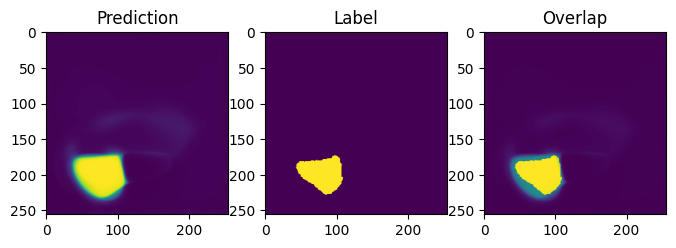

In [ ]:
l_image, l_label, _ = next(iter(labeled_loader))
u_image, _, _        = next(iter(unlabeled_loader))

l_image = l_image.to(device)
l_label = l_label.to(device)
u_image = u_image.to(device)

_, _, l_image_geo, l_label_geo, l_input = augment_samples(u_image, l_image, l_label)

model.eval()
with torch.no_grad():
    _, l_seg = model(l_input)
    l_seg = torch.softmax(l_seg, dim=1)

sample, channel = 0, 1

fig, ax = plt.subplots(1, 3, figsize=(8, 4))
ax[0].imshow(l_seg[sample, channel].detach().cpu())
ax[0].set_title('Prediction')
ax[1].imshow(l_label_geo[sample, channel].detach().cpu())
ax[1].set_title('Label')
ax[2].imshow((l_seg[sample, channel] + l_label_geo[sample, channel]).detach().cpu())
ax[2].set_title('Overlap')

print('Dice (this sample):', dice_score(l_label_geo[sample], l_seg[sample]))
print('Dice (batch mean): ', dice_score(l_label_geo, l_seg).mean().item())

## Evaluation — Dice + Hausdorff distance per class, on the held-out test set

In [16]:

evaluate(test_loader, desc='Evaluating (test)')

Evaluating (test): 100%|██████████| 177/177 [07:34<00:00,  2.57s/it]

Dice per class:
  Class 0 (background): 0.0190
  Class 1:                0.7102
  Class 2:                0.0004
  Class 3:                0.0042
  Class 4:                0.0692
  Class 5:                0.2543
  Class 6:                0.3583
  Class 7:                0.5346

Mean Dice (foreground 1-7): 0.2759
Mean Dice (all 8):          0.2438

IoU per class:
  Class 0 (background): 0.0096
  Class 1:                0.5550
  Class 2:                0.0004
  Class 3:                0.0042
  Class 4:                0.0640
  Class 5:                0.1570
  Class 6:                0.2282
  Class 7:                0.3936

Mean IoU (foreground 1-7): 0.2003
Mean IoU (all 8):          0.1765
Hausdorff distance per class (pixels):
  Class 0 (background): 241.96
  Class 1:                53.78
  Class 2:                214.65
  Class 3:                258.12
  Class 4:                218.61
  Class 5:                84.32
  Class 6:                167.06
  Class 7:                108.62

Mean

(tensor([1.9039e-02, 7.1019e-01, 3.5311e-04, 4.2373e-03, 6.9216e-02, 2.5426e-01,
         3.5830e-01, 5.3460e-01]),
 tensor([9.6416e-03, 5.5502e-01, 3.5311e-04, 4.2373e-03, 6.4027e-02, 1.5695e-01,
         2.2818e-01, 3.9361e-01]),
 tensor([241.9646,  53.7817, 214.6501, 258.1204, 218.6140,  84.3153, 167.0631,
         108.6169]))

## Visualize Predictions (generic)

In [ ]:
model.eval()
image, label = next(iter(test_loader))
image = image.to(device)

with torch.no_grad():
    rec, seg = model(image)
    pred_probs = torch.softmax(seg, dim=1).cpu()   # (B, num_classes, H, W)


def _show_image(ax, img):
    """imshow a (C, H, W) tensor channel-agnostically: grayscale for 1 channel,
    RGB for 3 (CelebAMask-HQ)."""
    img = img.detach().cpu()
    if img.shape[0] == 1:
        ax.imshow(img[0], cmap="gray")
    else:
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))


n_show = 4
n_cols = 2 + dataset_config['num_classes']
fig, axes = plt.subplots(n_show, n_cols, figsize=(3 * n_cols, 3 * n_show))

seg_ims = []
for i in range(n_show):
    _show_image(axes[i, 0], image[i])
    axes[i, 0].set_title("Input")
    axes[i, 0].axis("off")

    # rec[i] is (N, H, W) single-channel or (N, C, H, W) RGB — mean over vectorizers,
    # then display channel-agnostically.
    rec_i = rec[i].mean(0)
    _show_image(axes[i, 1], rec_i.unsqueeze(0) if rec_i.dim() == 2 else rec_i)
    axes[i, 1].set_title("Reconstruction")
    axes[i, 1].axis("off")

    for c in range(dataset_config['num_classes']):
        im = axes[i, 2 + c].imshow(pred_probs[i, c], cmap="hot", vmin=0, vmax=1)
        axes[i, 2 + c].set_title(f"Class {c}")
        axes[i, 2 + c].axis("off")
        seg_ims.append(im)

# shared colorbar over all segmentation axes
seg_axes = axes[:, 2:].ravel().tolist()
fig.colorbar(seg_ims[0], ax=seg_axes, shrink=0.6, label="Probability")

plt.suptitle("Segmentation probabilities (shared scale)", y=1.01)
plt.tight_layout()
plt.show()

## Test-Time Adaptation (generic)

In [ ]:
# Test-time adaptation: fine-tune on reconstruction only, then score Dice
for loops in range(20):
    class_dice = torch.zeros(dataset_config['num_classes'])
    n_batches  = 0
    for image, label in tqdm(test_loader, desc='Evaluating loops {}'.format(loops)):
        model.load_state_dict(torch.load(train_config['model_path'], map_location=device))
        image = image.to(device)
        target = label.float().argmax(dim=1).cpu()         # (B, H, W) class indices

        model.train()
        for i in range(loops):
            optimizer.zero_grad()
            rec, seg = model(image)
            r_loss = reconstruction_loss(rec, image, seg)
            loss = r_loss
            loss.backward()
            optimizer.step()

        model.eval()
        _, seg = model(image)
        pred = seg.argmax(dim=1).cpu()                     # (B, H, W)

        class_dice += compute_class_dice(pred, target, dataset_config['num_classes'])
        n_batches += 1

    class_dice /= n_batches
    print_dice_report(class_dice, dataset_config['num_classes'])

Evaluating loops 0: 100%|██████████| 23/23 [00:17<00:00,  1.29it/s]


Dice per class:
  Class 0 (background): 0.9688
  Class 1:                0.6963
  Class 2:                0.6583

Mean Dice (chambers 1-2): 0.6773
Mean Dice (all 3):        0.7744


Evaluating loops 1: 100%|██████████| 23/23 [00:23<00:00,  1.00s/it]


Dice per class:
  Class 0 (background): 0.9675
  Class 1:                0.6874
  Class 2:                0.6556

Mean Dice (chambers 1-2): 0.6715
Mean Dice (all 3):        0.7702


Evaluating loops 2: 100%|██████████| 23/23 [00:27<00:00,  1.19s/it]


...

Dice per class:
  Class 0 (background): 0.9696
  Class 1:                0.7035
  Class 2:                0.6619

Mean Dice (chambers 1-2): 0.6827
Mean Dice (all 3):        0.7783


Evaluating loops 6: 100%|██████████| 23/23 [00:46<00:00,  2.01s/it]


Dice per class:
  Class 0 (background): 0.9696
  Class 1:                0.7037
  Class 2:                0.6615

Mean Dice (chambers 1-2): 0.6826
Mean Dice (all 3):        0.7783


Evaluating loops 7:  48%|████▊     | 11/23 [00:25<00:27,  2.31s/it]


KeyboardInterrupt: 